In [15]:
from imblearn.under_sampling import TomekLinks
import pandas as pd

df = pd.read_csv('../../Exercise_project_1\Classification_dataset\mushroom_reduced.csv')
df.head()




<>:4: SyntaxWarning: invalid escape sequence '\C'
<>:4: SyntaxWarning: invalid escape sequence '\C'
C:\Users\svetl\AppData\Local\Temp\ipykernel_9080\1521604172.py:4: SyntaxWarning: invalid escape sequence '\C'
  df = pd.read_csv('../../Exercise_project_1\Classification_dataset\mushroom_reduced.csv')


,class,does-bruise-or-bleed,stem-height,stem-width,cap-surface_d,cap-surface_e,cap-surface_g,cap-surface_h,cap-surface_i,cap-surface_k,...,stem-color_g,stem-color_k,stem-color_l,stem-color_n,stem-color_o,stem-color_p,stem-color_r,stem-color_u,stem-color_w,stem-color_y
0,1,0,16.95,17.09,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,17.99,18.19,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,1,0,17.80,17.74,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,1,0,15.77,15.98,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
4,1,0,16.53,17.20,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0


In [16]:
df.columns

Index(['class', 'does-bruise-or-bleed', 'stem-height', 'stem-width',
       'cap-surface_d', 'cap-surface_e', 'cap-surface_g', 'cap-surface_h',
       'cap-surface_i', 'cap-surface_k', 'cap-surface_l',
       'cap-surface_missing', 'cap-surface_s', 'cap-surface_t',
       'cap-surface_w', 'cap-surface_y', 'gill-attachment_a',
       'gill-attachment_d', 'gill-attachment_e', 'gill-attachment_f',
       'gill-attachment_missing', 'gill-attachment_p', 'gill-attachment_s',
       'gill-attachment_x', 'gill-spacing_c', 'gill-spacing_d',
       'gill-spacing_f', 'gill-spacing_missing', 'gill-color_b',
       'gill-color_e', 'gill-color_f', 'gill-color_g', 'gill-color_k',
       'gill-color_n', 'gill-color_o', 'gill-color_p', 'gill-color_r',
       'gill-color_u', 'gill-color_w', 'gill-color_y', 'stem-color_b',
       'stem-color_e', 'stem-color_f', 'stem-color_g', 'stem-color_k',
       'stem-color_l', 'stem-color_n', 'stem-color_o', 'stem-color_p',
       'stem-color_r', 'stem-color_u', 'st

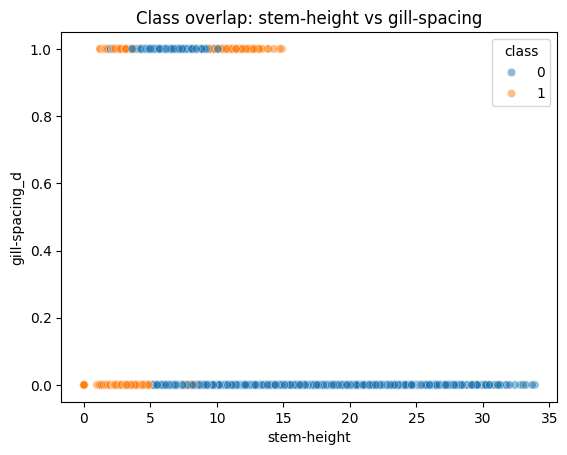

In [17]:
# Let's try to find overlapping in dataset
# on this plot we  can see that for both gill-spacing_d = 0 and gill-spacing_d = 1 blue and orange points do exist.
#  More of explanation i will write in the report. 
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x="stem-height",
    y="gill-spacing_d",
    hue="class",
    alpha=0.5
)

plt.title("Class overlap: stem-height vs gill-spacing")
plt.show()


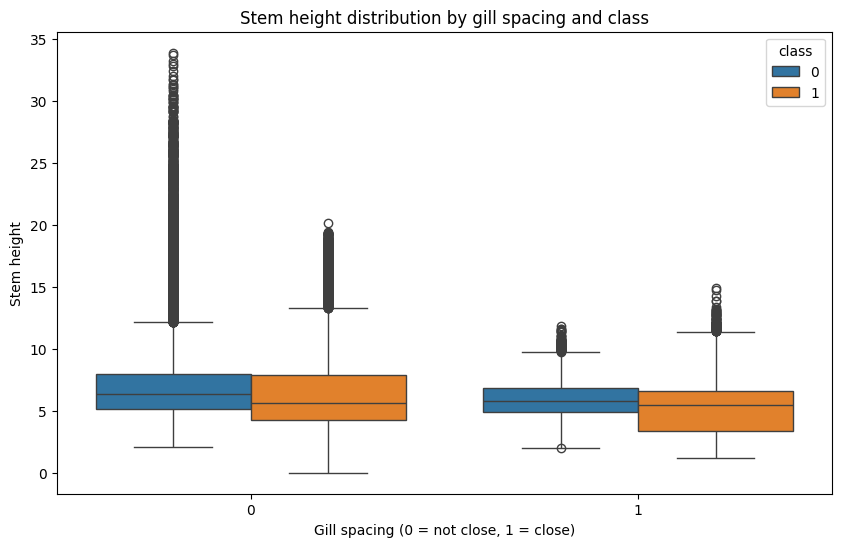

In [18]:
# on scatter plot we can see better the overlapping. Analysis in the report. 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.boxplot(
    x="gill-spacing_d",
    y="stem-height",
    hue="class",
    data=df
)

plt.title("Stem height distribution by gill spacing and class")
plt.xlabel("Gill spacing (0 = not close, 1 = close)")
plt.ylabel("Stem height")
plt.show()

<Axes: >

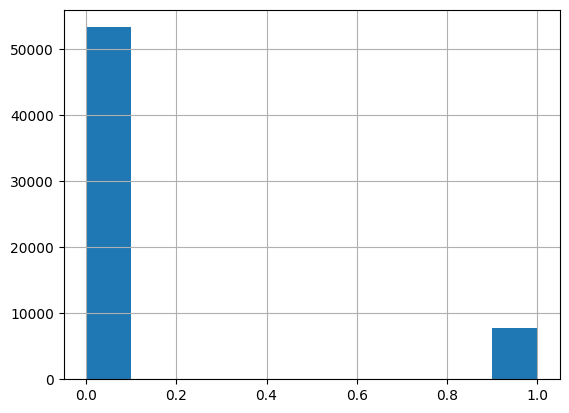

In [19]:
df['gill-spacing_d'].hist()

In [24]:
df['gill-spacing_d'].value_counts()

gill-spacing_d
0    53303
1     7766
Name: count, dtype: int64

In [20]:
# initialize TomekLinks
# TomekLinks is used to reduce data overlap throughout the dataset
# howewer, we can't really configure its parameters
tomek = TomekLinks()

# X/y -split
X = df.drop("gill-spacing_d", axis=1)
y = df['gill-spacing_d']

# create new resampled versions of X and y
X_resampled, y_resampled = tomek.fit_resample(X, y)

# re-create a new DataFrame
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['gill-spacing_d'] = y_resampled

In [21]:
df_resampled

,class,does-bruise-or-bleed,stem-height,stem-width,cap-surface_d,cap-surface_e,cap-surface_g,cap-surface_h,cap-surface_i,cap-surface_k,...,stem-color_k,stem-color_l,stem-color_n,stem-color_o,stem-color_p,stem-color_r,stem-color_u,stem-color_w,stem-color_y,gill-spacing_d
0,1,0,16.95,17.09,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,1,0,17.99,18.19,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,1,0,17.80,17.74,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,1,0,15.77,15.98,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
4,1,0,16.53,17.20,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61064,1,0,3.93,6.22,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
61065,1,0,3.18,5.43,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
61066,1,0,3.86,6.37,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
61067,1,0,3.56,5.44,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


<Axes: >

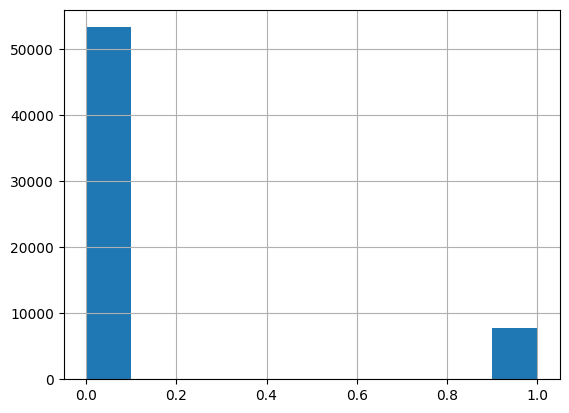

In [22]:
df_resampled['gill-spacing_d'].hist()

In [23]:
df_resampled['gill-spacing_d'].value_counts()

gill-spacing_d
0    53303
1     7766
Name: count, dtype: int64